# Matrix Product Operators: full ITensor approach

In [1]:
using Pkg
Pkg.activate("../")
using ITensors
using ITensorMPS
using Plots

  Activating project at `~/Library/CloudStorage/OneDrive-UniversitàdegliStudidiMilano/Work/Workspace/Unimi/Corsi/TN_Ulm/Materiale_dispense/TN_Notebooks`


## Extended example

We now simulate an XY model (with $\gamma=0) in the absence of the magnetic field. We take a chain of $N=20$ spins with Hamiltonian:
$$
H = -J \sum_{i=1}^{N-1} \sigma_-^{i} \sigma_+^{i+1} + \sigma_+^{i} \sigma_-^{i+1} - h \sum_{i=1}^N \sigma_i^z 
$$ 
with $J = 1.0$ $h=0.5$.

Notice that  the presence of a constant magnetic term would add an overall phase factor that does not alter the dynamics.

We initialize the system having the first site "up" and all the remaining elements "down"

In [2]:
nn = 20
jj=1.0
system = siteinds("S=1/2",nn)
#Prepare the initial state as a product state with "Up" on the first site and "Dn" on the rest of the sites
psi0= MPS(ComplexF64,system,[(j==1) ? "Up" : "Dn" for j in 1:nn]);
#Set the orthogonality center to the first site
orthogonalize!(psi0,1)


20-element MPS:
 ((dim=2|id=124|"S=1/2,Site,n=1"), (dim=1|id=314|"Link,l=1"))
 ((dim=2|id=305|"S=1/2,Site,n=2"), (dim=1|id=484|"Link,l=2"), (dim=1|id=314|"Link,l=1"))
 ((dim=2|id=921|"S=1/2,Site,n=3"), (dim=1|id=996|"Link,l=3"), (dim=1|id=484|"Link,l=2"))
 ((dim=2|id=822|"S=1/2,Site,n=4"), (dim=1|id=346|"Link,l=4"), (dim=1|id=996|"Link,l=3"))
 ((dim=2|id=49|"S=1/2,Site,n=5"), (dim=1|id=216|"Link,l=5"), (dim=1|id=346|"Link,l=4"))
 ((dim=2|id=721|"S=1/2,Site,n=6"), (dim=1|id=519|"Link,l=6"), (dim=1|id=216|"Link,l=5"))
 ((dim=2|id=111|"S=1/2,Site,n=7"), (dim=1|id=868|"Link,l=7"), (dim=1|id=519|"Link,l=6"))
 ((dim=2|id=241|"S=1/2,Site,n=8"), (dim=1|id=20|"Link,l=8"), (dim=1|id=868|"Link,l=7"))
 ((dim=2|id=203|"S=1/2,Site,n=9"), (dim=1|id=226|"Link,l=9"), (dim=1|id=20|"Link,l=8"))
 ((dim=2|id=546|"S=1/2,Site,n=10"), (dim=1|id=922|"Link,l=10"), (dim=1|id=226|"Link,l=9"))
 ((dim=2|id=140|"S=1/2,Site,n=11"), (dim=1|id=929|"Link,l=11"), (dim=1|id=922|"Link,l=10"))
 ((dim=2|id=686|"S=1/2,Site,n=

Let's do a test: average value of $\sigma_z$ on all sites (this morally belongs to the next lecture...):

In [3]:
function measureZ(psi::MPS,j::Int)
    #Measured site must be the orthogonality center
    orthogonalize!(psi,j)
    return scalar(dag(psi[j])*noprime(op("Z", system[j])*psi[j]))
end


measureZ (generic function with 1 method)

In [4]:
@show op("Z", system[1])

op("Z", system[1]) = ITensor ord=2
Dim 1: (dim=2|id=124|"S=1/2,Site,n=1")'
Dim 2: (dim=2|id=124|"S=1/2,Site,n=1")
NDTensors.Dense{Float64, Vector{Float64}}
 2×2
 1.0   0.0
 0.0  -1.0



ITensor ord=2 (dim=2|id=124|"S=1/2,Site,n=1")' (dim=2|id=124|"S=1/2,Site,n=1")
NDTensors.Dense{Float64, Vector{Float64}}

In [5]:
function measureProjUp(psi::MPS,j::Int)
    #Measured site must be the orthogonality center
    orthogonalize!(psi,j)
    return scalar(dag(psi[j])*noprime(op("ProjUp", system[j])*psi[j]))
end

function measureProjDn(psi::MPS,j::Int)
    #Measured site must be the orthogonality center
    orthogonalize!(psi,j)
    return scalar(dag(psi[j])*noprime(op("ProjDn", system[j])*psi[j]))
end


measureProjDn (generic function with 1 method)

In [6]:
using Plots

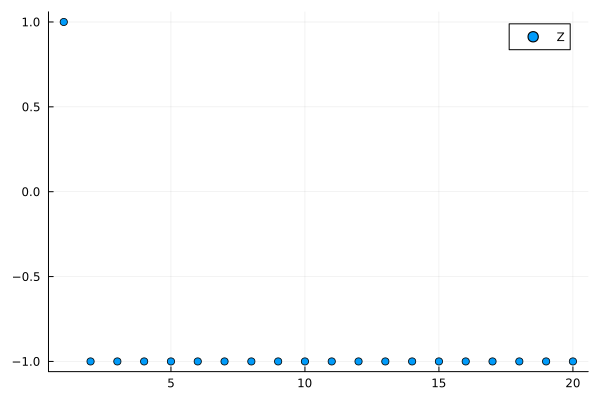

In [7]:
plot(real([measureZ(psi0,j) for j in 1:nn]), seriestype=:scatter, label="Z")

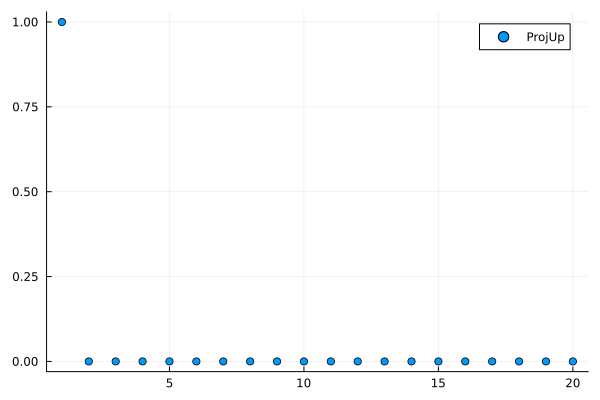

In [8]:
plot(real([measureProjUp(psi0,j) for j in 1:nn]), seriestype=:scatter, label="ProjUp")

Let us now turn our attention to the definition of the MPO.

In [94]:
show(op("Z", system[1]))

ITensor ord=2
Dim 1: (dim=2|id=175|"S=1/2,Site,n=1")'
Dim 2: (dim=2|id=175|"S=1/2,Site,n=1")
NDTensors.Dense{Float64, Vector{Float64}}
 2×2
 1.0   0.0
 0.0  -1.0


In [10]:
opsum = OpSum()
for site in 1:nn
    opsum += -0.5, "Z", site
end
for bond in 1:nn-1
    #note that the sintax allows for constants to appear before the operator string
    opsum += -1. * jj, "S-", bond, "S+", bond+1
    opsum += -1. * jj, "S+", bond, "S-", bond+1
end

# opsum = OpSum()
# for site in 1:nn
#     opsum += -0.5, "Z", site
# end
# for bond in 1:nn-1
#     #note that the sintax allows for constants to appear before the operator string
#     opsum += -1. * jj, "S-", bond, "S+", bond+1
#     opsum += -1. * jj, "S+", bond, "S-", bond+1
# end

#ham = MPO(ComplexF64,opsum, system; maxdim=1000, cutoff=1e-18);
ham = MPO(ComplexF64,opsum, system);

In [11]:
maxlinkdim(ham)

4

We know something about the Ising model. For example we know that the number of spin "up" (or "down") is a constant of the motion, i.e. it commutes with the Hamiltonian. Let's see if this holds at least for some power of $H$

In [13]:
nupOp = OpSum()
for j in 1:nn
    nupOp += 1.0, "ProjUp", j
end
nupMPO = MPO(ComplexF64, nupOp, system);
#nupMPO = MPO(ComplexF64, nupOp, system; maxdim=1000, cutoff=1e-18);

20-element MPO:
 ((dim=2|id=76|"Link,l=1"), (dim=2|id=124|"S=1/2,Site,n=1")', (dim=2|id=124|"S=1/2,Site,n=1"))
 ((dim=2|id=76|"Link,l=1"), (dim=2|id=736|"Link,l=2"), (dim=2|id=305|"S=1/2,Site,n=2")', (dim=2|id=305|"S=1/2,Site,n=2"))
 ((dim=2|id=736|"Link,l=2"), (dim=2|id=487|"Link,l=3"), (dim=2|id=921|"S=1/2,Site,n=3")', (dim=2|id=921|"S=1/2,Site,n=3"))
 ((dim=2|id=487|"Link,l=3"), (dim=2|id=311|"Link,l=4"), (dim=2|id=822|"S=1/2,Site,n=4")', (dim=2|id=822|"S=1/2,Site,n=4"))
 ((dim=2|id=311|"Link,l=4"), (dim=2|id=355|"Link,l=5"), (dim=2|id=49|"S=1/2,Site,n=5")', (dim=2|id=49|"S=1/2,Site,n=5"))
 ((dim=2|id=355|"Link,l=5"), (dim=2|id=657|"Link,l=6"), (dim=2|id=721|"S=1/2,Site,n=6")', (dim=2|id=721|"S=1/2,Site,n=6"))
 ((dim=2|id=657|"Link,l=6"), (dim=2|id=130|"Link,l=7"), (dim=2|id=111|"S=1/2,Site,n=7")', (dim=2|id=111|"S=1/2,Site,n=7"))
 ((dim=2|id=130|"Link,l=7"), (dim=2|id=911|"Link,l=8"), (dim=2|id=241|"S=1/2,Site,n=8")', (dim=2|id=241|"S=1/2,Site,n=8"))
 ((dim=2|id=911|"Link,l=8"), (d

...so far so good.

We now push a little forward. Suppose that we want to _evolve_ the state $\ket{\psi_0}$ under the action of $H$ for a time $\delta t$.

Since
$$
\exp(-i H \delta t) = \mathbb{1} -i H \delta t -\frac{1}{2} \left ( H \delta t \right )^2 + .. = \sum_k=\frac{(-i)^k}{k!} \left( H \delta t\right)^k
$$
for $\delta t $ small enough we could be satisfied with an order 3 ($k=0,1,2,3$) approximation of the expansion.


In [14]:
deltat = 0.01 #NOTE: in MPO_ITensor it was 0.1, but with the current parameters it is not stable, so I reduced it to 0.01
nsteps = Int(round(10/deltat))
hdeltat = deltat * ham
#build an MPO with the operator "Id" on each site
theOne = MPO(system,"Id")
factor(k) = (-1im)^k / factorial(k)
#As not to have all the indices of hdeltat contracted with each other, we prime the second one and then we contract the first index of the second one with the first index of the first one, and then we lower the second prime level to first prime level.
# h2 = mapprime(prime(hdeltat)*hdeltat,2 =>1)
# h2 = mapprime(contract(prime(hdeltat),hdeltat;mindim=8,maxdim=1000, cutoff=1e-18),2 =>1)
# h3 = mapprime(contract(prime(hdeltat),h2;mindim=8,maxdim=1000, cutoff=1e-18),2 =>1)
h2 = mapprime(contract(prime(hdeltat),hdeltat),2 =>1)
h3 = mapprime(contract(prime(hdeltat),h2),2 =>1)
terms = [theOne, factor(1)*hdeltat, factor(2)*h2, factor(3)*h3];
appo = add(terms...)
#appo = add(terms..., cutoff=1e-18,mindim=8,maxdim=1000)
#appo = terms[1];
# for t in terms[2:end]
#     appo = t + appo
# end
h4thOrder = appo;
#h4thOrder = +(terms...; cutoff=1e-18);

20-element MPO:
 ((dim=2|id=124|"S=1/2,Site,n=1")', (dim=2|id=124|"S=1/2,Site,n=1"), (dim=12|id=708|"Link,l=1"))
 ((dim=2|id=305|"S=1/2,Site,n=2")', (dim=2|id=305|"S=1/2,Site,n=2"), (dim=14|id=262|"Link,l=2"), (dim=12|id=708|"Link,l=1"))
 ((dim=2|id=921|"S=1/2,Site,n=3")', (dim=2|id=921|"S=1/2,Site,n=3"), (dim=14|id=756|"Link,l=3"), (dim=14|id=262|"Link,l=2"))
 ((dim=2|id=822|"S=1/2,Site,n=4")', (dim=2|id=822|"S=1/2,Site,n=4"), (dim=14|id=716|"Link,l=4"), (dim=14|id=756|"Link,l=3"))
 ((dim=2|id=49|"S=1/2,Site,n=5")', (dim=2|id=49|"S=1/2,Site,n=5"), (dim=14|id=244|"Link,l=5"), (dim=14|id=716|"Link,l=4"))
 ((dim=2|id=721|"S=1/2,Site,n=6")', (dim=2|id=721|"S=1/2,Site,n=6"), (dim=14|id=618|"Link,l=6"), (dim=14|id=244|"Link,l=5"))
 ((dim=2|id=111|"S=1/2,Site,n=7")', (dim=2|id=111|"S=1/2,Site,n=7"), (dim=14|id=736|"Link,l=7"), (dim=14|id=618|"Link,l=6"))
 ((dim=2|id=241|"S=1/2,Site,n=8")', (dim=2|id=241|"S=1/2,Site,n=8"), (dim=14|id=876|"Link,l=8"), (dim=14|id=736|"Link,l=7"))
 ((dim=2|id=20

In [15]:
println(maxlinkdim(h3))
println(maxlinkdim(h4thOrder))

14
17


In [16]:
deltat^3 *10

1.0000000000000003e-5

In [17]:
h4thOrder == dag(h4thOrder)

false

Let us evolve the initial state for one time step $\delta t$

fast forward:

In [21]:
evolved = Vector{MPS}()
push!(evolved, psi0)
for j=2:nsteps
    #push!(evolved, apply(h4thOrder, evolved[end]; mindim=15, maxdim = 1000))
    push!(evolved, noprime(h4thOrder * evolved[end]))
end

In [22]:
evolved[end]

20-element MPS:
 ((dim=2|id=384|"Link,l=1"), (dim=2|id=124|"S=1/2,Site,n=1"))
 ((dim=2|id=305|"S=1/2,Site,n=2"), (dim=2|id=666|"Link,l=2"), (dim=2|id=384|"Link,l=1"))
 ((dim=2|id=921|"S=1/2,Site,n=3"), (dim=2|id=466|"Link,l=3"), (dim=2|id=666|"Link,l=2"))
 ((dim=2|id=822|"S=1/2,Site,n=4"), (dim=2|id=128|"Link,l=4"), (dim=2|id=466|"Link,l=3"))
 ((dim=2|id=49|"S=1/2,Site,n=5"), (dim=2|id=254|"Link,l=5"), (dim=2|id=128|"Link,l=4"))
 ((dim=2|id=721|"S=1/2,Site,n=6"), (dim=2|id=869|"Link,l=6"), (dim=2|id=254|"Link,l=5"))
 ((dim=2|id=111|"S=1/2,Site,n=7"), (dim=2|id=841|"Link,l=7"), (dim=2|id=869|"Link,l=6"))
 ((dim=2|id=241|"S=1/2,Site,n=8"), (dim=2|id=595|"Link,l=8"), (dim=2|id=841|"Link,l=7"))
 ((dim=2|id=203|"S=1/2,Site,n=9"), (dim=2|id=54|"Link,l=9"), (dim=2|id=595|"Link,l=8"))
 ((dim=2|id=546|"S=1/2,Site,n=10"), (dim=2|id=955|"Link,l=10"), (dim=2|id=54|"Link,l=9"))
 ((dim=2|id=140|"S=1/2,Site,n=11"), (dim=2|id=266|"Link,l=11"), (dim=2|id=955|"Link,l=10"))
 ((dim=2|id=686|"S=1/2,Site,n=

In [23]:
norm.(evolved)

1000-element Vector{Float64}:
 1.0
 0.9999970716679756
 0.9999941433477063
 0.9999912150391923
 0.9999882867424548
 0.9999853584575202
 0.9999824301844168
 0.9999795019232668
 0.9999765736740981
 0.9999736454369897
 ⋮
 0.9971038329348271
 0.9971009171043386
 0.9970980012682019
 0.9970950854260103
 0.9970921695773801
 0.9970892537219507
 0.9970863378593859
 0.9970834219893707
 0.9970805061116155

In [191]:
anim = @animate for i=1:10:nsteps
    fig = plot(real([measureProjUp(evolved[i],j)/norm(evolved[i]) for j in 1:nn]), seriestype=:scatter, label="ProjUp")
    plot!(fig, real([measureProjUp(evolved[i],j)/norm(evolved[i]) for j in 1:nn]))
end;
gif(anim, "evolutionMag.gif", fps=10);

┌ Info: Saved animation to /Users/Tama/Library/CloudStorage/OneDrive-UniversitàdegliStudidiMilano/Work/Workspace/Unimi/Corsi/TN_Ulm/Materiale_dispense/TN_Notebooks/Lecture3/evolutionMag.gif
└ @ Plots /Users/Tama/.julia/packages/Plots/GIume/src/animation.jl:156


Total number of spin up:

In [24]:
[inner(a',nupMPO,a)/norm(a) for a in evolved]

1000-element Vector{ComplexF64}:
                1.0 + 0.0im
 0.9999970716679756 - 2.737276775182422e-18im
 0.9999941433477065 + 6.8341891809018896e-18im
 0.9999912150391931 - 5.912956364856136e-18im
 0.9999882867424568 - 7.258342251829637e-18im
 0.9999853584575229 - 1.8537343857019658e-17im
  0.999982430184422 + 2.1271045751148477e-17im
 0.9999795019232726 - 4.683153714380303e-17im
 0.9999765736741068 - 4.29887374201972e-17im
 0.9999736454370007 - 3.1674468133151326e-17im
                    ⋮
    0.9971038329456 + 1.1360464024442685e-17im
 0.9971009171151424 - 5.724469460400178e-19im
 0.9970980012790371 + 3.647078686649896e-17im
 0.9970950854368757 + 2.1874165496364483e-16im
 0.9970921695882773 - 6.256730529752737e-17im
 0.9970892537328758 - 5.928848723161483e-18im
 0.9970863378703444 - 2.707252024667435e-17im
 0.9970834220003598 - 1.0376155900510052e-17im
 0.9970805061226354 - 3.129131475112583e-17im

We have an exact solution of the isotropic Ising chain.

In [25]:
eigVals(n,k) = -2*jj*cos(k * π / (n+1))
eigVecs(n,k) = sqrt(2/(n+1)) * [sin(j * k * π / (n+1)) for j in 1:n]

eigVecs (generic function with 1 method)

In [26]:
norm(eigVecs(20,1)  )

0.9999999999999999

In [27]:
exactSol(n,t,init::Vector{ComplexF64}) = sum(exp(-1im * eigVals(n,k) * t) * eigVecs(n,k)* eigVecs(n,k)' * init for k in 1:n) 

exactSol (generic function with 1 method)

In [28]:
[norm(exactSol(nn,0.1*(i-1), ComplexF64.([1.0; zeros(nn-1)]))) for i=1:100]

100-element Vector{Float64}:
 0.9999999999999999
 0.9999999999999999
 1.0
 1.0
 1.0
 0.9999999999999999
 1.0
 1.0
 1.0
 1.0000000000000002
 ⋮
 1.0
 1.0
 1.0
 1.0
 1.0
 1.0000000000000002
 1.0
 1.0000000000000002
 1.0000000000000002

In [31]:
anim = @animate for i=1:10:nsteps
    fig = plot(real([measureProjUp(evolved[i],j) for j in 1:nn]), seriestype=:scatter, label="MPO")
    plot!(fig, real([measureProjUp(evolved[i],j) for j in 1:nn]),label="MPO")
    plot!(fig, abs.(exactSol(nn,deltat*(i-1), ComplexF64.([1.0; zeros(nn-1)]))) .^ 2, label="Exact")
    plot!(fig, (abs.(exactSol(nn,deltat*(i-1), ComplexF64.([1.0; zeros(nn-1)])))).^ 2, label="Exact",seriestype=:scatter)
end;
gif(anim, "evolutionCheckMag.gif", fps=10);

┌ Info: Saved animation to /Users/Tama/Library/CloudStorage/OneDrive-UniversitàdegliStudidiMilano/Work/Workspace/Unimi/Corsi/TN_Ulm/Materiale_dispense/TN_Notebooks/Lecture3/evolutionCheckMag.gif
└ @ Plots /Users/Tama/.julia/packages/Plots/GIume/src/animation.jl:156
